In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [ ]:
# Base dataset
df = pd.read_csv("../../Data/Processed/renttherunway_clean.csv")

# GMM clusters
gmm = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/gmm_df.csv")[["user_id", "item_id", "body_cluster", "cluster_confidence"]]

# DBSCAN clusters
dbscan = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/dbscan_df.csv")[["user_id", "dbscan_cluster"]]

# K-Means clusters
kmeans = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/kmeans_clusters.csv").rename(columns={"cluster": "kmeans_cluster"})

# LDA topic features
lda = pd.read_csv("../../Data/Processed/Unsupervised_Outputs/renttherunway_lda_topics.csv")

In [3]:
df = df.merge(
    dbscan,
    on="user_id",
    how="left"
)

In [4]:
df = df.merge(
    gmm,
    on=["user_id", "item_id"],
    how="left"
)

In [5]:
df = df.merge(
    kmeans,
    on=["user_id", "item_id"],
    how="left"
)

In [6]:
df = df.merge(
    lda,
    on=["user_id", "item_id", "fit", "fit_label"],
    how="left"
)

In [7]:
df["is_outlier"] = (df["dbscan_cluster"] == -1).astype(int)

In [8]:
NUMERIC_FEATURES = [
    "height_inches",
    "weight_lbs",
    "bmi",
    "age",
    "bust_band",
    "cup_size_num"
]

CLUSTER_FEATURES = [
    "dbscan_cluster",
    "body_cluster",
    "kmeans_cluster"
]

BINARY_FEATURES = ["is_outlier"]

TOPIC_FEATURES = [c for c in df.columns if c.startswith("topic_")]

In [9]:
X = df[
    NUMERIC_FEATURES
    + CLUSTER_FEATURES
    + BINARY_FEATURES
    + TOPIC_FEATURES
]

y = df["fit_label"].astype(int)

In [10]:
assert y.notna().all()

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
preprocessor = ColumnTransformer(
    transformers=[
        # Numeric + topic features
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            NUMERIC_FEATURES + TOPIC_FEATURES
        ),

        # Cluster features (categorical)
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CLUSTER_FEATURES
        ),

        # Binary features
        (
            "bin",
            SimpleImputer(strategy="constant", fill_value=0),
            BINARY_FEATURES
        )
    ],
    remainder="drop"
)

In [13]:
cart = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)

In [14]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", cart)
])

In [15]:
param_grid = {
    "model__max_depth": [4, 6, 8, 12],
    "model__min_samples_leaf": [50, 100, 200],
    "model__min_samples_split": [100, 200, 500]
}

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [17]:
grid = GridSearchCV(
    pipeline,
    param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END model__max_depth=4, model__min_samples_leaf=50, model__min_samples_split=100; total time=   8.6s
[CV] END model__max_depth=4, model__min_samples_leaf=50, model__min_samples_split=500; total time=  10.8s
[CV] END model__max_depth=4, model__min_samples_leaf=50, model__min_samples_split=200; total time=  10.9s
[CV] END model__max_depth=4, model__min_samples_leaf=50, model__min_samples_split=500; total time=  11.3s
[CV] END model__max_depth=4, model__min_samples_leaf=50, model__min_samples_split=200; total time=  11.3s
[CV] END model__max_depth=4, model__min_samples_leaf=50, model__min_samples_split=500; total time=  11.3s
[CV] END model__max_depth=4, model__min_samples_leaf=50, model__min_samples_split=200; total time=  11.6s
[CV] END model__max_depth=4, model__min_samples_leaf=50, model__min_samples_split=100; total time=  11.7s
[CV] END model__max_depth=4, model__min_samples_leaf=50, model__min_samples_split=200; tot

/Users/hkbuttar/Machine-Learning-Final-Project/venv/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__max_depth=4, model__min_samples_leaf=200, model__min_samples_split=200; total time=  13.6s
[CV] END model__max_depth=4, model__min_samples_leaf=200, model__min_samples_split=200; total time=   9.1s
[CV] END model__max_depth=4, model__min_samples_leaf=200, model__min_samples_split=200; total time=   9.0s
[CV] END model__max_depth=4, model__min_samples_leaf=200, model__min_samples_split=200; total time=  13.3s
[CV] END model__max_depth=4, model__min_samples_leaf=200, model__min_samples_split=500; total time=   9.1s
[CV] END model__max_depth=4, model__min_samples_leaf=200, model__min_samples_split=500; total time=   9.3s
[CV] END model__max_depth=4, model__min_samples_leaf=200, model__min_samples_split=500; total time=   9.1s
[CV] END model__max_depth=4, model__min_samples_leaf=200, model__min_samples_split=500; total time=   9.2s
[CV] END model__max_depth=4, model__min_samples_leaf=200, model__min_samples_split=500; total time=   9.1s
[CV] END model__max_depth=6, model__m

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [4, 6, ...], 'model__min_samples_leaf': [50, 100, ...], 'model__min_samples_split': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

In [18]:
best_cart = grid.best_estimator_

y_test_pred = best_cart.predict(X_test)

print("Best CART parameters:")
print(grid.best_params_)

print("\nCART — Test Set Performance")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Small", "Fit", "Large"]
))

Best CART parameters:
{'model__max_depth': 12, 'model__min_samples_leaf': 50, 'model__min_samples_split': 100}

CART — Test Set Performance
              precision    recall  f1-score   support

       Small       0.39      0.73      0.51     34494
         Fit       0.89      0.73      0.80    174054
       Large       0.70      0.70      0.70     57738

    accuracy                           0.73    266286
   macro avg       0.66      0.72      0.67    266286
weighted avg       0.78      0.73      0.74    266286



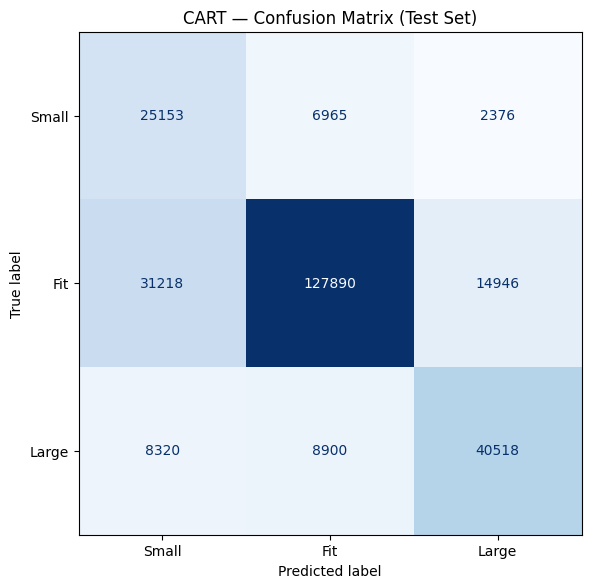

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    display_labels=["Small", "Fit", "Large"],
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("CART — Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("../../Figures/Supervised_Outputs/cart_confusion_matrix.png", dpi=300)
plt.show()

In [ ]:
cart_proba = best_cart.predict_proba(X_test)

cart_proba_df = pd.DataFrame({
    "user_id": df.loc[X_test.index, "user_id"],
    "item_id": df.loc[X_test.index, "item_id"],
    "true_fit": y_test.values,
    "prob_small": cart_proba[:, 0],
    "prob_fit": cart_proba[:, 1],
    "prob_large": cart_proba[:, 2]
})

cart_proba_df.to_csv(
    "../../Data/Processed/Supervised_Outputs/cart_fit_probabilities.csv",
    index=False
)

In [ ]:
import joblib

joblib.dump(
    best_cart,
    "../../Models/cart_fit_classifier.joblib"
)

['../Models/cart_fit_classifier.joblib']

In [22]:
# After fitting
prep = best_cart.named_steps["prep"]

feature_names = []

# Numeric + topic features
feature_names.extend(NUMERIC_FEATURES + TOPIC_FEATURES)

# Cluster features (after one-hot)
cat_encoder = prep.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(CLUSTER_FEATURES)
feature_names.extend(cat_feature_names)

# Binary features
feature_names.extend(BINARY_FEATURES)

In [23]:
importances = best_cart.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

In [ ]:
importance_df.head(20).to_csv(
    "../../Data/Processed/Supervised_Outputs/cart_feature_importances.csv",
    index=False
)

## CART — Model Performance Writeup

### Overview
A single Classification and Regression Tree (CART) was trained on the same clothing fit classification task, predicting **Small**, **Fit**, or **Large**. Grid search identified optimal hyperparameters of `max_depth=12`, `min_samples_leaf=50`, and `min_samples_split=100`. As a standalone decision tree, this model serves as a natural baseline for comparison against the ensemble Bagging Classifier.

---

### Overall Performance
The CART model achieved **73% accuracy** on the 266,286-sample test set, with a weighted F1-score of **0.74**. Both figures trail the Bagging Classifier (77% accuracy, 0.79 weighted F1), which is expected — bagging's variance reduction gives it a structural advantage over a single tree.

---

### Class-Level Analysis

**Fit (Majority Class)**
Still the strongest class, with **0.89 precision** and an F1 of **0.80**. However, recall dropped to **0.73** compared to 0.79 in the Bagging model, meaning the CART tree lets more true Fit items slip into other categories — notably 31,218 misclassified as Small (vs. 27,495 for Bagging). This suggests greater instability in the Fit/Small boundary when relying on a single tree.

**Large**
Performance is balanced but modest at **0.70 precision, 0.70 recall**, and an F1 of **0.70**. Compared to Bagging (F1 = 0.75), the single tree struggles more with Large, with 14,946 true Large items misclassified as Fit — a notably higher leakage rate than the ensemble's 9,277.

**Small (Minority Class)**
The weakest class again, with precision of only **0.39** and F1 of **0.51** — both lower than Bagging's already-concerning 0.43 precision and 0.56 F1. Of 34,494 true Small items, only 25,153 were correctly classified, and the model predicts Small liberally, capturing a large number of false positives from the Fit class. The class imbalance problem is more pronounced here without the variance-smoothing effect of bagging.

---

### Comparison to Bagging Classifier

| Metric | CART | Bagging | Δ |
|---|---|---|---|
| Accuracy | 73% | 77% | +4% (Bagging) |
| Weighted F1 | 0.74 | 0.79 | +0.05 (Bagging) |
| Small F1 | 0.51 | 0.56 | +0.05 (Bagging) |
| Fit F1 | 0.80 | 0.84 | +0.04 (Bagging) |
| Large F1 | 0.70 | 0.75 | +0.05 (Bagging) |

Bagging outperforms CART consistently across every class and metric — a textbook demonstration of how ensemble methods reduce the high variance inherent in individual decision trees.

---

### Key Takeaways
| Metric | Value |
|---|---|
| Overall Accuracy | 73% |
| Best Class | Fit (F1 = 0.80) |
| Weakest Class | Small (F1 = 0.51, precision = 0.39) |
| Primary Error Mode | Fit items predicted as Small (31,218 cases) |

CART provides an interpretable, computationally lightweight baseline, but the performance gap relative to the Bagging Classifier is meaningful across all classes. For a production fit recommendation system, the added complexity of bagging is well justified by the gains — particularly for the already-challenging Small class.